# Neural Network

### handwritten digits recognition 

- MNIST dataset
    - 70000 datasets [0-9]
    - each image is of 28 * 28 px
    - Training : 60k
    - Testing : 10k
    - images are in grey scale [0-1]
    - labels are OneHotEncoding eg 3: [0,0,0,1,0,0,0,0,0,0]

- Problem : 
    - Over fitting
    - Under fitting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')

/Users/pembagelusherpa/.pyenv/versions/3.11.5/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
### Load our dataset

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("training images : ",x_train.shape)
print("testing images : ",x_test.shape)

training images :  (60000, 28, 28)
testing images :  (10000, 28, 28)


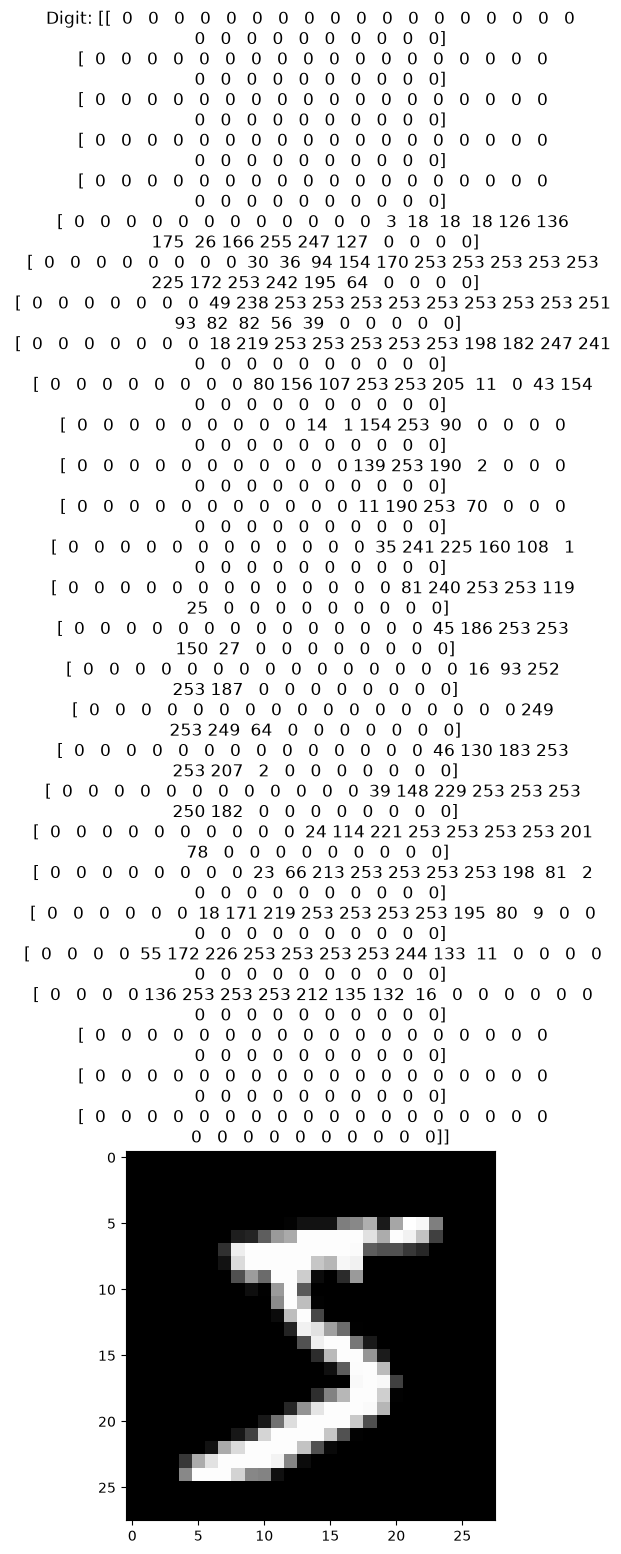

In [3]:
### display images

plt.imshow(x_train[0],cmap ='gray')
plt.title(f"Digit: {x_train[0]}")
plt.show()

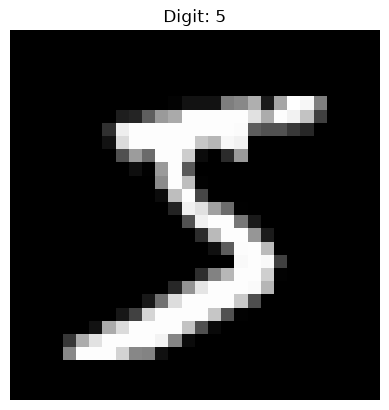

In [4]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Digit: {y_train[0]}")
plt.axis("off")      # Optional: hides the x and y axes
plt.show()

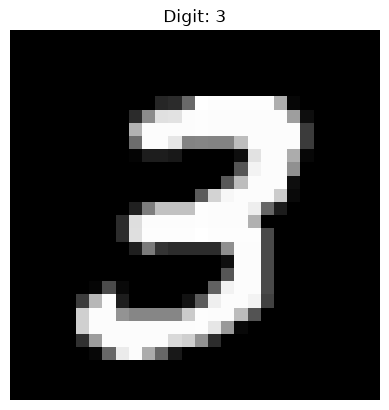

In [5]:
plt.imshow(x_train[7], cmap='gray')
plt.title(f"Digit: {y_train[7]}")
plt.axis("off")      # Optional: hides the x and y axes
plt.show()

## Preprocess the data
### 1. change pixel value from 0-255 to 0-1(Normalization)

In [6]:
x_train = x_train/255
x_test = x_test/255

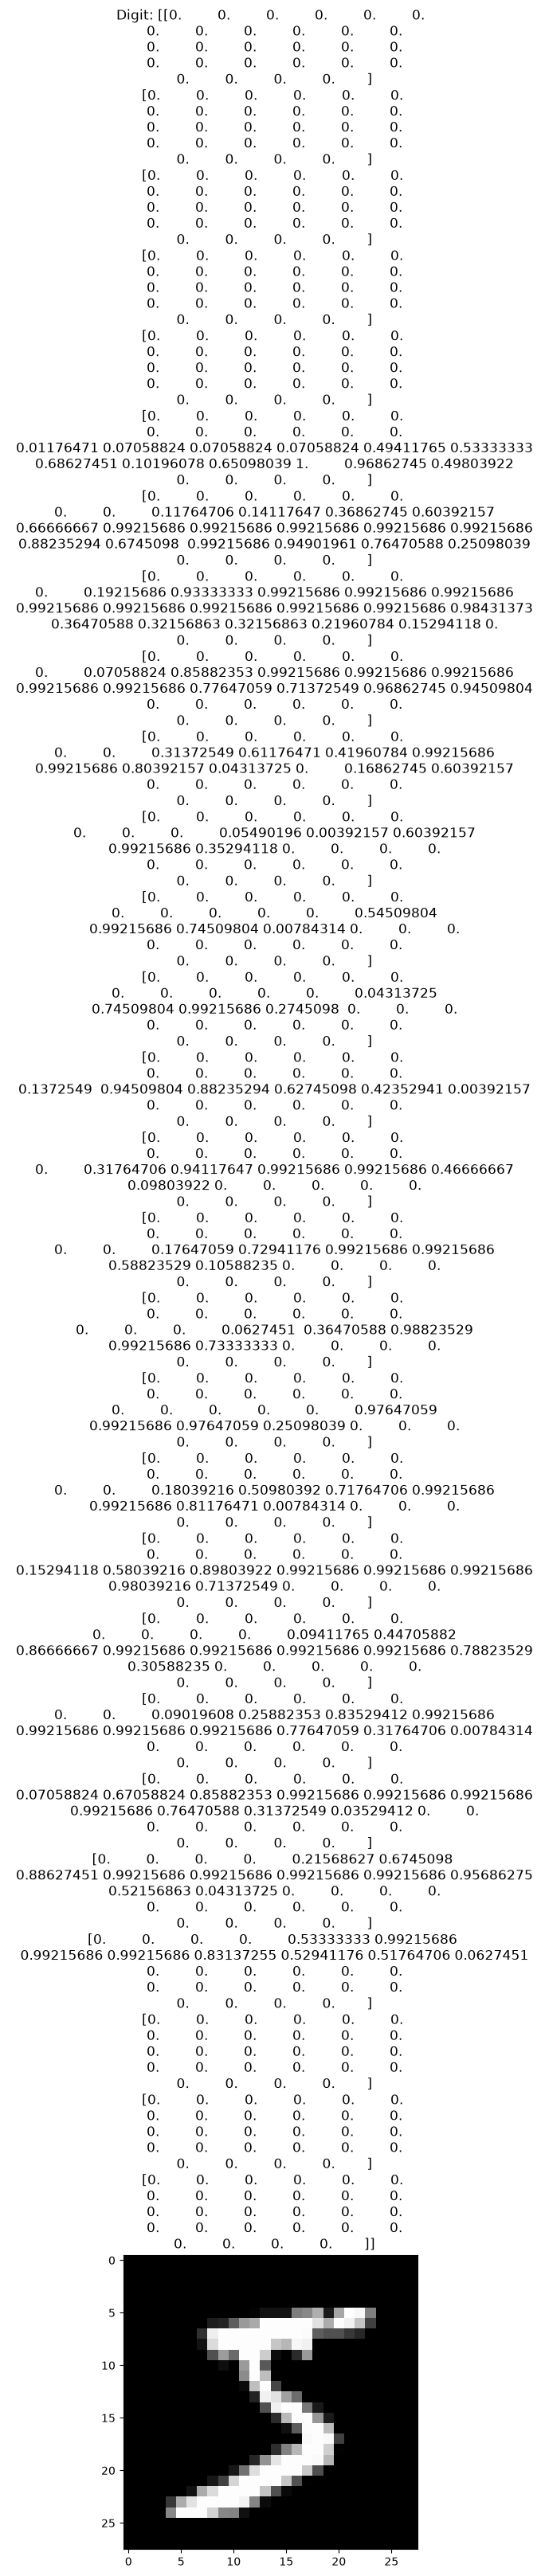

In [7]:
### display images

plt.imshow(x_train[0],cmap ='gray')
plt.title(f"Digit: {x_train[0]}")
plt.show()

### 2. One-Hot Encoding e.g 5 = [0 0 0 0 0 1 0 0 0 0}

In [8]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

##### 3. Build the free-forward neural network

- layer 1: flatten(2d to 1d) (convertes 28*28 image into vector of 784 values)
- layer 2: dense layer (128) (fully connected nueral network layer with 784 neurones use activation RELU)
- layer 3: dense layer (64) (hidden layer with 64 elements, use activation ReLU)
- layer 4: dense layer (10 [0-9]) (for probability we are using softmax activation)

In [9]:
model = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

##### 4. Compile the model

- Optimizer: adam
    - Adjust weight efficiently during training

- loss: categorical_crossentropy
    - It measures error for multi class classification

- metrics : accuracy
    - Track the % of correct prediction

In [13]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

##### 5. Train the model

- epos = 10
    - entire dataset passes through network 10 times

- batch_size = 128
    - process 128 samples before updating the weight

- validation_split = 0.1
    - use 10% of data for validation

In [15]:
history = model.fit(
    x_train,
    y_train,
    epochs = 10,
    batch_size = 128,
    validation_split = 0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9044 - loss: 0.3423 - val_accuracy: 0.9635 - val_loss: 0.1386
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9574 - loss: 0.1434 - val_accuracy: 0.9683 - val_loss: 0.1115
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9698 - loss: 0.1000 - val_accuracy: 0.9705 - val_loss: 0.1003
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9778 - loss: 0.0752 - val_accuracy: 0.9755 - val_loss: 0.0851
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9825 - loss: 0.0579 - val_accuracy: 0.9753 - val_loss: 0.0829
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9859 - loss: 0.0459 - val_accuracy: 0.9785 - val_loss: 0.0764
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9882 - loss: 0.0383 - val_accuracy: 0.9793 - val_loss: 0.0748
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9906 - loss: 0.0308 - val_accuracy: 0.

#### EVALUATION OF MODEL

In [16]:
loss, accuracy = model.evaluate(x_test,y_test)

print(f"The model is {accuracy*100}% accurate, with the loss of {loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - accuracy: 0.9776 - loss: 0.0784
The model is 97.75999784469604% accurate, with the loss of 0.0783606618642807


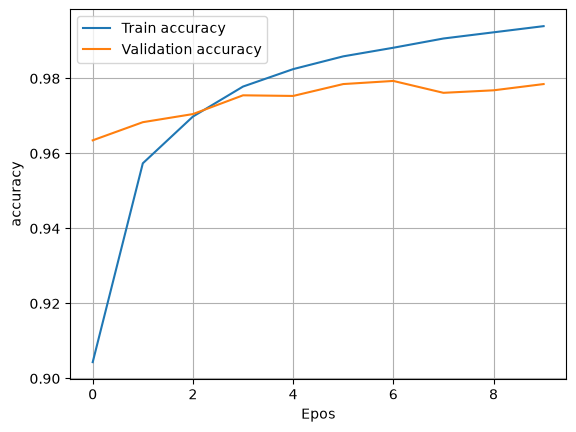

In [ ]:
# plot 
plt.plot(history.history['accuracy'], label = "Train accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation accuracy")

plt.xlabel("Epos")
plt.ylabel("accuracy")
plt.legend()
plt.grid()

## test and make prediction

In [24]:
model.save("mnist.h5")

print("Model saved successfully")

Model saved successfully


## CNN (Convolutional Neural Network)